# PA3 Section 2.2 — LunarLander Report Plots

Loads existing 6-seed results and generates all required plots for the report.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sac_core import plot_curves, aggregate_runs, load_log

LOG_DIR = "logs"
N_SEEDS = 6
SAVE_DIR = "report_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

def paths(tag): return [os.path.join(LOG_DIR, f"{tag}_seed{s}.json") for s in range(N_SEEDS)]

cont_paths = paths("cont_auto")
hover_fixed_paths = paths("hover_fixed")
hover_auto_paths = paths("hover_auto")
disc_paths = paths("disc_sac")
dqn_paths = paths("dqn")

# Verify all logs exist
for p in cont_paths + hover_fixed_paths + hover_auto_paths + disc_paths + dqn_paths:
    assert os.path.exists(p), f"Missing: {p}"
print(f"All {5*N_SEEDS} logs found.")

All 30 logs found.


## Q1. Continuous SAC with automated α [4M]

Average undiscounted return vs. environment timesteps for continuous LunarLander with auto-tuned temperature.

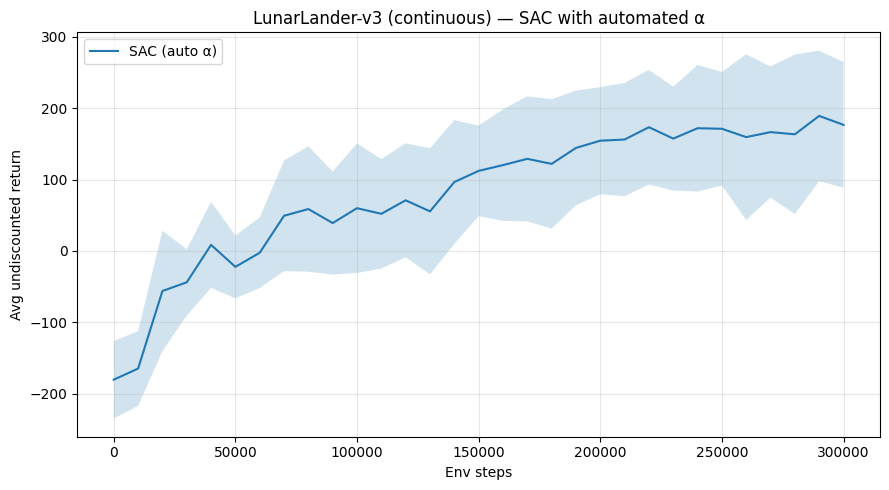

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_curves(ax, {"SAC (auto α)": cont_paths},
            title="LunarLander-v3 (continuous) — SAC with automated α")
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "q1_cont_auto.png"), dpi=200, bbox_inches='tight')
plt.show()

## Q2. Behavior analysis [4M]

Describe initial, intermediate, and final stages of the SAC agent. Identify local optima.

In [3]:
# Print summary stats at different training stages
steps, mean, lo, hi = aggregate_runs(cont_paths)
n_evals = len(steps)
stages = {
    'Initial (step 0)': 0,
    'Early (10% training)': n_evals // 10,
    'Mid (50% training)': n_evals // 2,
    'Final': -1
}
for name, idx in stages.items():
    print(f"{name}: step={steps[idx]:,.0f}, return={mean[idx]:.1f} [{lo[idx]:.1f}, {hi[idx]:.1f}]")

Initial (step 0): step=0, return=-180.5 [-234.7, -126.3]
Early (10% training): step=30,000, return=-44.1 [-90.4, 2.3]
Mid (50% training): step=150,000, return=112.1 [48.7, 175.5]
Final: step=300,000, return=176.6 [88.4, 264.7]


## Q3. Hover-box reward switch (+200 → −100) [7M + 7M]

Two SAC versions: fixed α=0.01 and auto α. Train with +200 hover reward, then switch to −100.

(a) Compare learning curves before and after reward change.  
(b) Discussion of maximum entropy formulation of SAC.

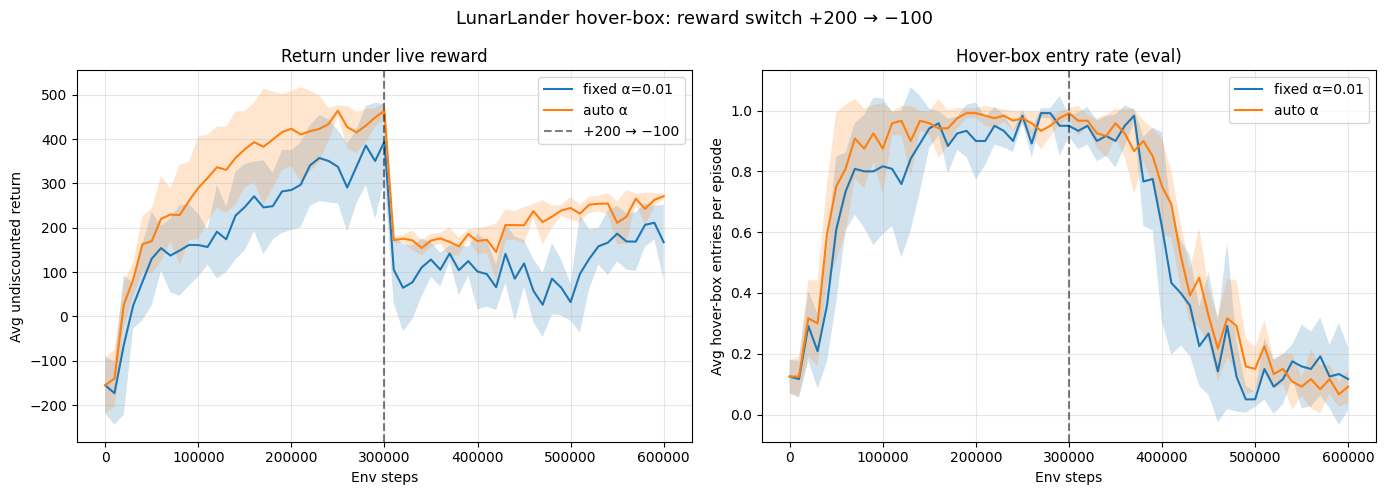

In [4]:
# Load hover config to get flip step
hover_cfg = json.load(open(os.path.join(LOG_DIR, "hover_auto_seed0.config.json")))
flip_step = hover_cfg.get("flip_step", 300000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Return under live reward
plot_curves(axes[0], {"fixed α=0.01": hover_fixed_paths, "auto α": hover_auto_paths},
            title="Return under live reward")
axes[0].axvline(flip_step, color="k", linestyle="--", alpha=0.5, label="+200 → −100")
axes[0].legend()

# Right: Hover-box entry rate
plot_curves(axes[1], {"fixed α=0.01": hover_fixed_paths, "auto α": hover_auto_paths},
            key="hover_hits", ylabel="Avg hover-box entries per episode",
            title="Hover-box entry rate (eval)")
axes[1].axvline(flip_step, color="k", linestyle="--", alpha=0.5)

fig.suptitle("LunarLander hover-box: reward switch +200 → −100", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "q3_hover_switch.png"), dpi=200, bbox_inches='tight')
plt.show()

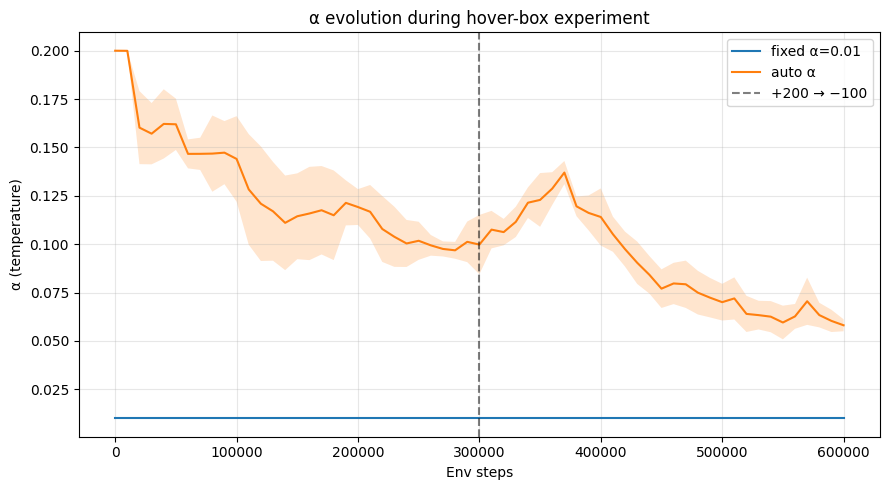

In [5]:
# Alpha evolution for hover experiments
fig, ax = plt.subplots(figsize=(9, 5))
plot_curves(ax, {"fixed α=0.01": hover_fixed_paths, "auto α": hover_auto_paths},
            key="alpha", ylabel="α (temperature)",
            title="α evolution during hover-box experiment")
ax.axvline(flip_step, color="k", linestyle="--", alpha=0.5, label="+200 → −100")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "q3_hover_alpha.png"), dpi=200, bbox_inches='tight')
plt.show()

## Q4. Discrete SAC and DQN [4M + 3M + 3M + 4M]

(b) Discrete SAC on LunarLander.  
(c) DQN vs. Discrete SAC comparison.

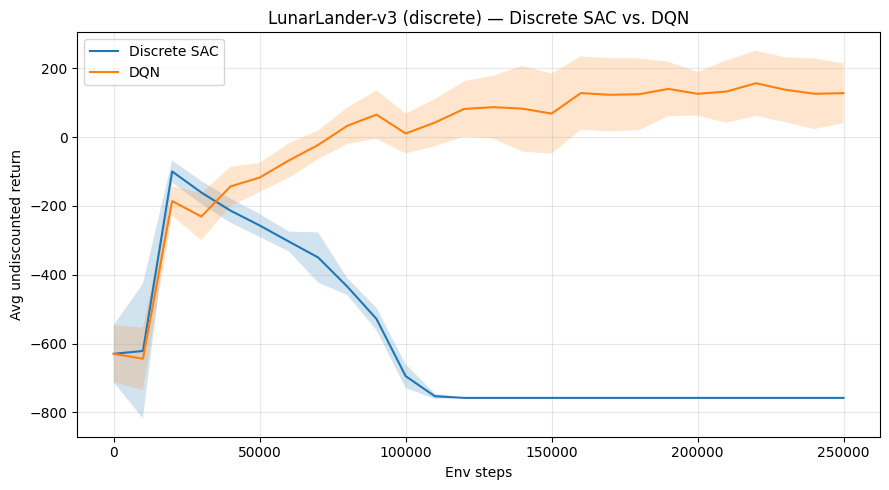

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_curves(ax, {"Discrete SAC": disc_paths, "DQN": dqn_paths},
            title="LunarLander-v3 (discrete) — Discrete SAC vs. DQN")
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "q4_disc_sac_vs_dqn.png"), dpi=200, bbox_inches='tight')
plt.show()

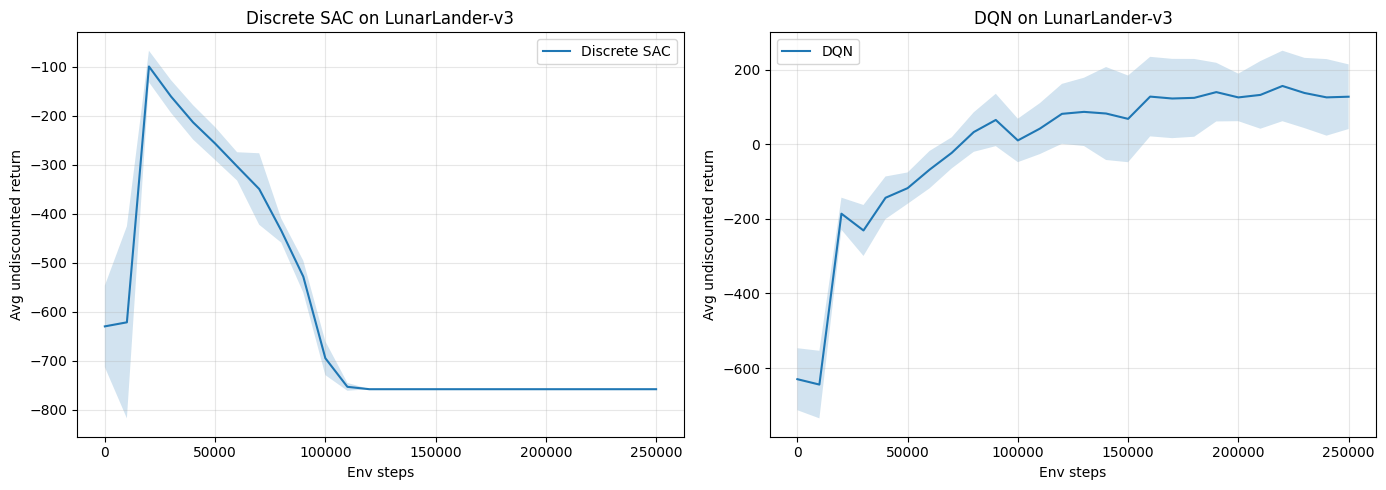

In [7]:
# Separate plots for disc_sac and dqn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_curves(axes[0], {"Discrete SAC": disc_paths},
            title="Discrete SAC on LunarLander-v3")
plot_curves(axes[1], {"DQN": dqn_paths},
            title="DQN on LunarLander-v3")

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "q4_disc_sac_and_dqn_separate.png"), dpi=200, bbox_inches='tight')
plt.show()

## Combined: All 2.2 experiments

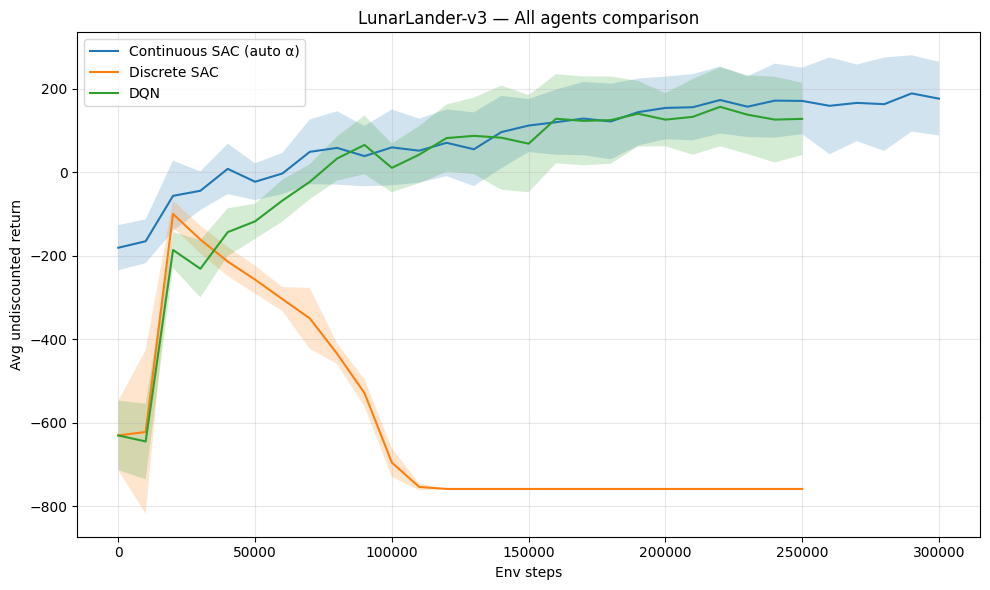

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_curves(ax, {
    "Continuous SAC (auto α)": cont_paths,
    "Discrete SAC": disc_paths,
    "DQN": dqn_paths,
}, title="LunarLander-v3 — All agents comparison")
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "all_agents_comparison.png"), dpi=200, bbox_inches='tight')
plt.show()

## Final summary statistics

In [9]:
import pandas as pd

results = []
for name, p in [("Cont SAC (auto α)", cont_paths),
                ("Hover fixed α=0.01", hover_fixed_paths),
                ("Hover auto α", hover_auto_paths),
                ("Discrete SAC", disc_paths),
                ("DQN", dqn_paths)]:
    steps, mean, lo, hi = aggregate_runs(p)
    final_returns = [load_log(f)["returns"][-1] for f in p]
    results.append({
        "Experiment": name,
        "Final return (mean)": f"{np.mean(final_returns):.1f}",
        "Final return (std)": f"{np.std(final_returns, ddof=1):.1f}",
        "95% CI": f"±{1.96*np.std(final_returns,ddof=1)/np.sqrt(len(final_returns)):.1f}",
        "N seeds": len(p),
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))
df.to_csv(os.path.join(SAVE_DIR, "summary_table.csv"), index=False)

        Experiment Final return (mean) Final return (std) 95% CI  N seeds
 Cont SAC (auto α)               176.6              110.1  ±88.1        6
Hover fixed α=0.01               167.3              105.6  ±84.5        6
      Hover auto α               271.1                6.7   ±5.4        6
      Discrete SAC              -758.2                0.0   ±0.0        6
               DQN               128.2              108.5  ±86.8        6


## Hyperparameters

In [10]:
for tag in ["cont_auto", "hover_auto", "hover_fixed", "disc_sac", "dqn"]:
    cfg_path = os.path.join(LOG_DIR, f"{tag}_seed0.config.json")
    if os.path.exists(cfg_path):
        cfg = json.load(open(cfg_path))
        print(f"\n=== {tag} ===")
        for k in ['total_steps', 'initial_random_steps', 'replay_buffer_size',
                   'batch_size', 'gamma', 'tau', 'actor_lr', 'critic_lr', 'alpha_lr',
                   'autotune_alpha', 'init_alpha', 'target_entropy',
                   'target_entropy_ratio', 'eval_every', 'eval_episodes',
                   'hover_bonus', 'flip_step']:
            if k in cfg:
                print(f"  {k}: {cfg[k]}")


=== cont_auto ===
  total_steps: 300000
  initial_random_steps: 10000
  replay_buffer_size: 1000000
  batch_size: 256
  gamma: 0.99
  tau: 0.005
  actor_lr: 0.0003
  critic_lr: 0.0003
  alpha_lr: 0.0003
  autotune_alpha: True
  init_alpha: 0.2
  target_entropy: -2
  eval_every: 10000
  eval_episodes: 20
  hover_bonus: None

=== hover_auto ===
  total_steps: 600000
  initial_random_steps: 10000
  replay_buffer_size: 100000
  batch_size: 256
  gamma: 0.99
  tau: 0.005
  actor_lr: 0.0003
  critic_lr: 0.0003
  alpha_lr: 0.0003
  autotune_alpha: True
  init_alpha: 0.2
  target_entropy: -2
  eval_every: 10000
  eval_episodes: 20

=== hover_fixed ===
  total_steps: 600000
  initial_random_steps: 10000
  replay_buffer_size: 100000
  batch_size: 256
  gamma: 0.99
  tau: 0.005
  actor_lr: 0.0003
  critic_lr: 0.0003
  alpha_lr: 0.0003
  autotune_alpha: False
  init_alpha: 0.01
  target_entropy: -2
  eval_every: 10000
  eval_episodes: 20

=== disc_sac ===
  total_steps: 250000
  initial_random_st